In [1]:
import matplotlib.pyplot as plt
import numpy as np
from p3.aoSystem.fourierModel import fourierModel
from p3.aoSystem.frequencyDomain import frequencyDomain
from p3.aoSystem.FourierUtils import radial_profile

/home/mmenessini/.conda/envs/tiptop/lib/python3.11/site-packages/cupy/_environment.py:663: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


Cupy import failed. P3 will fall back to CPU use.


/home/mmenessini/.conda/envs/tiptop/lib/python3.11/site-packages/cupy/_environment.py:663: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


Cupy import failed. MASTSEL will fall back to CPU use.


/home/mmenessini/.conda/envs/tiptop/lib/python3.11/site-packages/cupy/_environment.py:663: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


Cupy import failed. SEEING will fall back to CPU use.


/home/mmenessini/.local/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12010). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
fname = 'EKARUS'
fao = fourierModel(path_ini=f'/raid1/mmenessini/git/P3/p3/aoSystem/parFiles/{fname}.ini',display=False, verbose=True,getErrorBreakDown=True)

extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2

_____ ERROR BREAKDOWN  ON-AXIS_____
------------------------------------------
.Image Strehl at 0.75micron:	72.12%
.Maréchal Strehl at 0.75micron:	71.21%
.Residual wavefront error:	69.55nm
.NCPA residual:			0.00nm
.Fitting error:			35.98nm
.Differential refraction:	0.00nm
.Chromatic error:		0.00nm
.Aliasing error:		6.47nm
.Noise error:			40.04nm
.Spatio-temporal error:		43.57nm
.Wind-shake error:		0.00nm
.Additionnal jitter:		0.00mas / 0.00nm
.Extra error:			0.00nm
-------------------------------------------
.Sole servoLag error:		43.57nm
.Sole reconstruction error:	0.00nm
-------------------------------------------
.Sole anisoplanatism error:	0.00nm
-------------------------------------------

EXECUTION TIME BREAKDOWN

Total calculation time:                         3754.1 ms
AO system model initialization:                   11.3 ms

--

Text(0.5, 1.0, 'Aliasing')

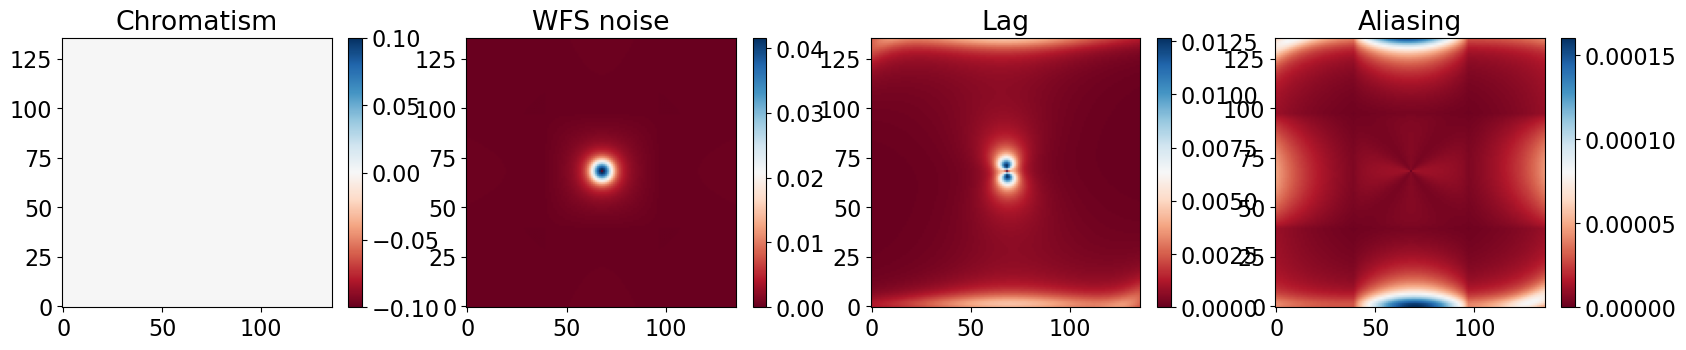

In [4]:
aliasPSD = fao.aliasingPSD()
servoLagPSD = fao.servoLagPSD()
# fittingPSD = fao.fittingPSD()
noisePSD = fao.noisePSD()
chromoPSD = fao.chromatismPSD()[:,:,0]

plt.figure(figsize=(20,3.5))
plt.subplot(1,4,1)
plt.imshow(chromoPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Chromatism')
plt.subplot(1,4,2)
plt.imshow(noisePSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('WFS noise')
plt.subplot(1,4,3)
plt.imshow(servoLagPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Lag')
plt.subplot(1,4,4)
plt.imshow(aliasPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Aliasing')

(0.0, 30.0)

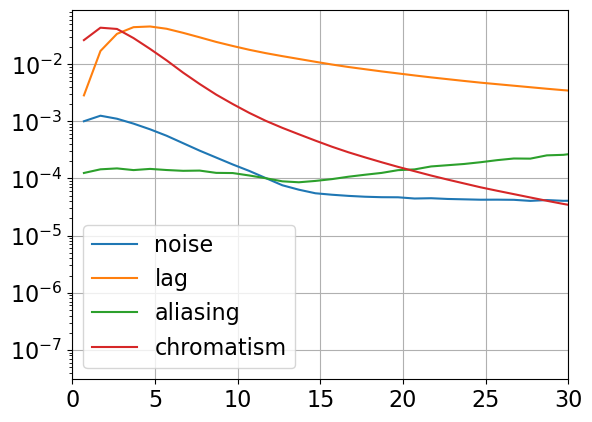

In [4]:
rad_bin, noise_profile = radial_profile(noisePSD)
rad_bin, lag_profile = radial_profile(servoLagPSD)
rad_bin, alias_profile = radial_profile(aliasPSD)
rad_bin, chromo_profile = radial_profile(chromoPSD)

plt.figure()
plt.semilogy(rad_bin, noise_profile,label='noise')
plt.semilogy(rad_bin, lag_profile,label='lag')
plt.semilogy(rad_bin, alias_profile,label='aliasing')
plt.semilogy(rad_bin, chromo_profile,label='chromatism')
# plt.semilogy(rad_bin_fit[::2], fit_profile[::2],label='fitting')
plt.legend()
plt.grid()
plt.xlim([0,30])

In [12]:
def get_flux(fao, mag:float, B0=10**10):
    thrp = fao.ao.wfs.detector[0].transmittance[0]
    area = np.pi/4*fao.ao.tel.D**2*(1-fao.ao.tel.obsRatio**2)
    # thrp *= 1.0-np.exp(-(0.35+0.72*fao.ao.wfs.optics[0].modulation))
    return area * thrp * B0 * 10**(-mag/2.5)

def update_ao_pars(fao, delay=None, gain=None, mag=None, seeing=None, fs=None, Nsubap=None, nModes=None, rMod=None, binning=None):

    if seeing is not None:
        fao.ao.atm.r0 = 0.98*500e-9/seeing*180/np.pi*3600
    
    if gain is not None:
        fao.ao.rtc.holoop['gain'] = gain
    if delay is not None:
        fao.ao.rtc.holoop['delay'] = delay
    if fs is not None:
        fao.ao.rtc.holoop['rate'] = fs
    if rMod is not None:
        fao.ao.wfs.optics[0].modulation = rMod
    if Nsubap is not None:
        fao.ao.wfs.optics[0].nL = Nsubap
        fao.ao.wfs.optics[0].dsub = fao.ao.tel.D/Nsubap

    if binning is not None:
        fao.ao.wfs.detector[0].binning = binning
                
    if mag is not None:
        total_flux = get_flux(fao, mag)
    else:
        total_flux = fao.ao.wfs.detector[0].nph * fao.ao.rtc.holoop['rate'] * fao.ao.wfs.optics[0].nL**2 * np.pi/4
    fs = fao.ao.rtc.holoop['rate']
    nSubap = fao.ao.wfs.optics[0].nL**2 * np.pi/4
    flux_per_sub = total_flux / fs / nSubap
    fao.ao.wfs.detector[0].nph = flux_per_sub

    if nModes is not None:
        nActs = np.sqrt(nModes*4/np.pi)
        fao.ao.dms.nActu1D = nActs
        fao.ao.dms.pitch = fao.ao.tel.D/nActs
        fao.freq = frequencyDomain(
                    fao.ao,
                    nyquistSampling=fao.nyquistSampling,
                    computeFocalAnisoCov=fao.computeFocalAnisoCov,
                    dtype=fao.dtype
                )
    
    fao.ao.wfs.processing.noiseVar = [None]
    

def get_error_breakdown(fao):
    fao.ao.error = False
    fao.getErrorBreakdown = True
    fao.initComputations()

    # try:
    idCenter = fao.ao.src.zenith.argmin()
    error = {'fitting': fao.wfeFit, 'lag': fao.wfeS, 'noise': fao.wfeN[idCenter], 'aliasing': fao.wfeAl, 'total': fao.wfeTot[idCenter]}
    # except IndexError:
    #     error = {'fitting': fao.wfeFit, 'noise': fao.wfeN, 'aliasing': fao.wfeAl, 'lag': fao.wfeS, 'total': fao.wfeTot}

    return error

fao.verbose = False

In [ ]:
# eb0 = get_error_breakdown(fao)
# # print(fao.ao.wfs.detector[0].nph)
# update_ao_pars(fao, rMod=0, seeing=2.0) #mag = 7.5, fs = 1500, delay = 3.5, gain = 0.5, 
# eb1 = get_error_breakdown(fao)
# print(eb0,'\n',eb1)

In [ ]:
seeings = np.array([1.0,1.5,2.0,2.5,3.0])
mags = np.array([1,3,5,7,9,11,13])

freqs = np.arange(50,1050,step=50)
gains = np.arange(0.1,1.0,11)

fitvec = np.zeros([len(seeings),len(mags)])
noisevec = np.zeros([len(seeings),len(mags)])
lagvec = np.zeros([len(seeings),len(mags)])
aliasvec = np.zeros([len(seeings),len(mags)])
bestgain = np.zeros([len(seeings),len(mags)])
bestfreq = np.zeros([len(seeings),len(mags)])

rMod = 5
tau = 1.5e-3

for i,seeing in enumerate(seeings):
    for j,mag in enumerate(mags):
        update_ao_pars(fao, mag=mag, seeing=seeing, rMod=rMod)
        min_tot = np.inf
        for freq in freqs:
            for gain in gains:
                update_ao_pars(fao, delay=1+tau*freq, gain=gain, fs=freq)
                eb = get_error_breakdown(fao)
                if fao.wfeTot < min_tot:
                    min_tot = fao.wfeTot
                    fitvec[i,j] = fao.wfeFit
                    noisevec[i,j] = fao.wfeN[0]
                    lagvec[i,j] = fao.wfeS
                    aliasvec[i,j] = fao.wfeAl
                    bestgain[i,j] = gain
                    bestfreq[i,j] = freq